# The Vision of the Future

## A deep dive into OpenCV using Python

Before we begin: Matplotlib and OpenCV use different channels to display images. CV uses BGR but Matplotlib uses RGB. Before we display any image on Matplotlib, we will convert it into RGB.

### Importing the necessary libraries:

In [3]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

### Detecting the path to the image:

In [4]:
# the path to the image
path = "iecse.jpeg"

### OpenCV reading the image:

In [5]:
# -1: read as default, 0: read as grayscale, 1: read as colour
image = cv2.imread(path, 1)

### OpenCV displaying the image:

(-0.5, 224.5, 224.5, -0.5)

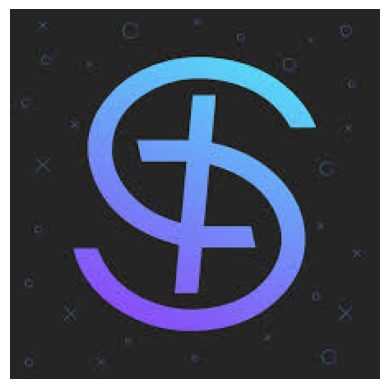

In [6]:
# OpenCV uses BGR by default, Matplotlib uses RGB by default. 
# Here, we convert BGR to RGB
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.axis("off") # plt as a graphing tool by default prints the x and y axis. we don't need those for images

#cv2.imshow("Title for the window", image) works here too! We're using matplotlib
#because it allows us to show the image inside the jupyter notebook.

### Drawing shapes on the canvas:

The general rule for the parameters are:
1. Specify the image that OpenCV needs to draw stuff on
2. For lines and rectangles, specify the bottom-left and top-right points.
   For circles, specify the centre point and the radius.
3. Next, specify the colour of the shape you'd like to draw (B, G, R)
4. Finally, specify the thickness (always integer) of the shape

(-0.5, 224.5, 224.5, -0.5)

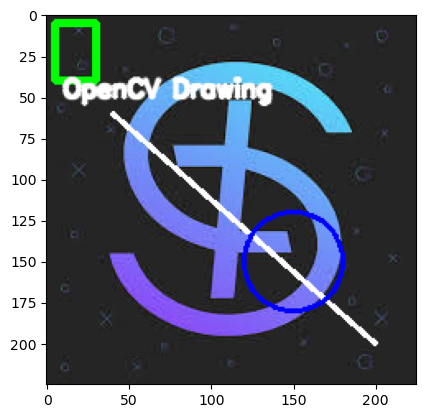

In [7]:
# image, start, end, (R, G, B) colour, thickness
cv2.line(image, (200, 200), (40, 60), (255, 255, 255), 2) #thickness must be an integer!

# image, start, end, (R, G, B) colour, thickness
cv2.rectangle(image, (5, 5), (30, 40), (0, 255, 0), 3)

# image, centre, radius, (R, G, B) colour, thickness
cv2.circle(image, (150, 150), 30, (0, 0, 255), 2)

# font for the image
font = cv2.FONT_HERSHEY_SIMPLEX

# put text 'OpenCV Drawing' on image - position, font, size, (R, G, B) colour, 
cv2.putText(image, 'OpenCV Drawing', (10, 50), font, 0.5, (255, 255, 255), 2, cv2.LINE_AA)

plt.imshow(image)
plt.axis("on")

### Accessing and storing your webcam

It's important to note that each frame read can be treated like one separate image

In [8]:
# this isn't very relevant now - we'll talk about it later.
face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')


# create a VideoCapture object for webcam (index 0)
cap = cv2.VideoCapture(0)

# the webcam's outputs details
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))

# fourcc is an OpenCV add-on to help store images
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
# naming the output file
out = cv2.VideoWriter('output.mp4', fourcc, fps, (width, height))

# check whether the webcam has opened
if not cap.isOpened():
    print("Error: Could not open webcam.")
    exit()

# read and display frames in an inf loop till "q" is pressed
i = 0
while True:
    
    # reads one frame from VideoCapture
    ret, frame = cap.read()
    
    # if frame is read correctly, ret is True
    if not ret:
        print("Error: Failed to capture frame.")
        break
    
    # writing frame number on the image frame
    i+=1
    cv2.putText(frame, f"Display of frame {i}", (10, 50), font, 2, (255, 255, 255), 1, cv2.LINE_AA)

    # face detection - you'll understand this part later.
    faces_detected = face_cascade.detectMultiScale(frame, 10, 3)
    for (x, y, w, h) in faces_detected:
        cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 5)
        cv2.putText(frame, "Hey there!", (x, y - 20), font, 1, (0, 255, 0), 2, cv2.LINE_AA)
    
    
    # storing our frame (with all our edits) into out.
    out.write(frame)
    # display the frame till the next frame is passed
    cv2.imshow('Webcam', frame)
    
    # break the loop when 'q' is pressed, consequently ending the recording
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# release the webcam and close all windows
cap.release()
out.release()
cv2.destroyAllWindows()


qt.qpa.plugin: Could not find the Qt platform plugin "wayland" in "/home/pratham/.local/lib/python3.10/site-packages/cv2/qt/plugins"


### You should see your output.mp4 file saved in your project directory now

## Analysing colour channels

### RGB / BGR

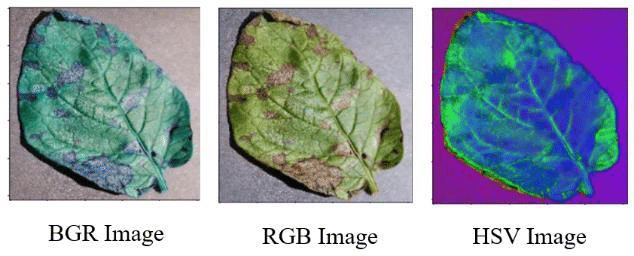

There are 3 primary colours: Red, Green and Blue. Any image and colour can be constructed by overlaying 3 2D matrices of R, G and B values.

In digital images, RGB channels represent the intensity of red, green, and blue light at each pixel, allowing for the creation of a wide range of colors through their combination.

Each pixel, therefore, consists of 3 values: the intensity of R, G and B.

Here's two examples:

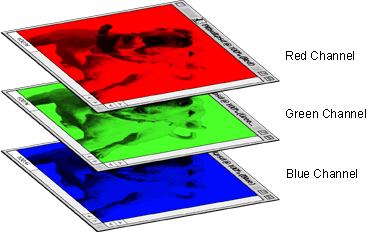

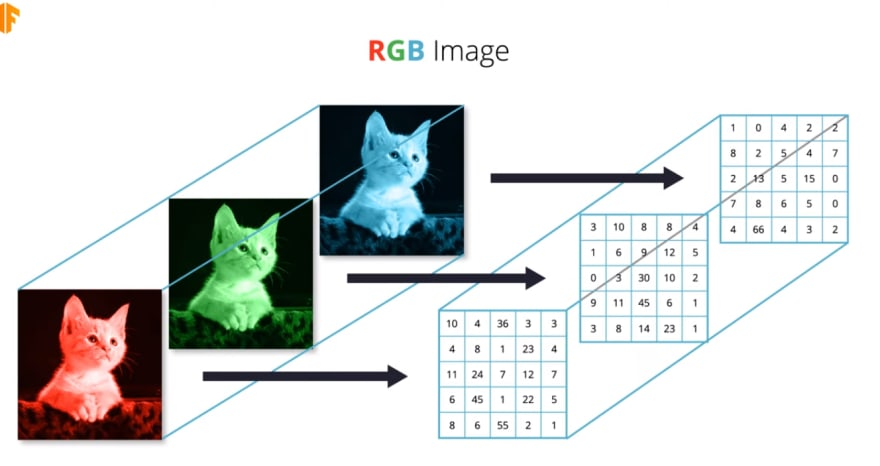

### HSV

The HSV channel module converts the image into a hue, saturation, and value/lightness components instead of the RGB representation. The Hue is the color of the image, the Saturation is the pureness of the hue color, and the value is the strength of the hue.

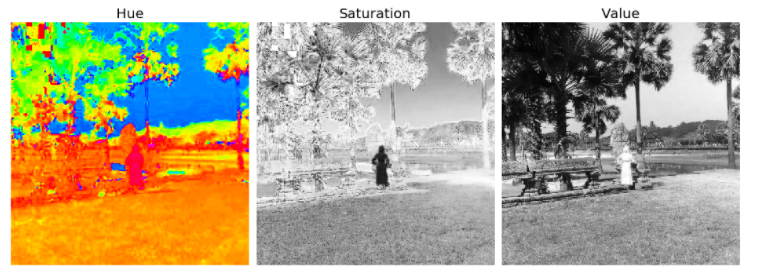

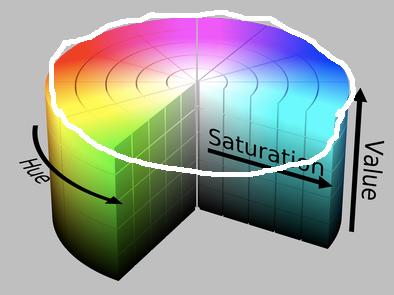


Most image processing and displaying platforms consider the RGB colour scheme. But OpenCV considers the BGR scheme, swapping the positions of B and R.

Thus, when Matplotlib (RGB) shows an image read by OpenCV (BGR), the blue and red channels are swapped.

This would be a serious issue, but OpenCV provides tools to convert channels from one to the other using cv2.cvtColor()

Let's take an example of an RGB image of a cute golden retriever <3

Text(0.5, 1.0, 'BGR (incorrectly read) v/s RGB v/s HSV')

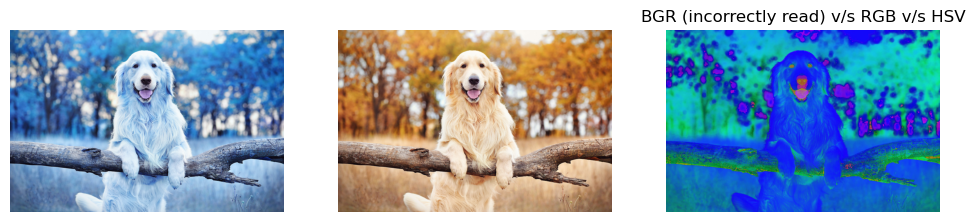

In [9]:
goldie = cv2.imread("cv_goldie.jpg", 1) # reads as BGR even though most other platform
# read images as RGB

# fix this by converting color channels into RGB
goldie_rgb = cv2.cvtColor(goldie, cv2.COLOR_BGR2RGB)

# hue, saturation, value color channels
goldie_hsv = cv2.cvtColor(goldie, cv2.COLOR_BGR2HSV)

fig, (a1, a2, a3) = plt.subplots(1,3, figsize=(12, 14))
a1.imshow(goldie)
a1.axis("off")
a2.imshow(goldie_rgb)
a2.axis("off")
a3.imshow(goldie_hsv)
a3.axis("off")
plt.title("BGR (incorrectly read) v/s RGB v/s HSV")

## Color Extraction

(-0.5, 224.5, 224.5, -0.5)

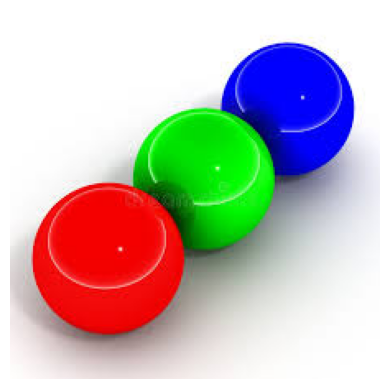

In [10]:
balls = cv2.imread("bgr.jpeg", 1)
balls = cv2.cvtColor(balls, cv2.COLOR_BGR2RGB)

plt.imshow(balls)
plt.axis("off")

Here we define lower and upper bounds for the colour channels.

(-0.5, 224.5, 224.5, -0.5)

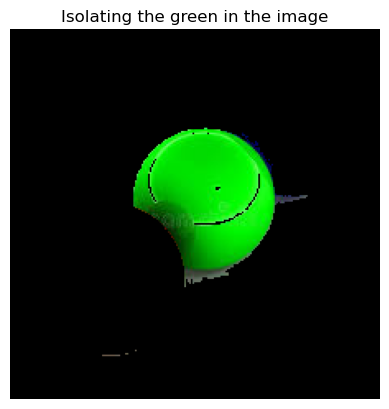

In [11]:

lower_green = np.array([0, 0, 0])
upper_green = np.array([110, 255, 100])

# Create a mask using the color range
mask = cv2.inRange(balls, lower_green, upper_green)

# apply the mask onto the result
result = cv2.bitwise_and(balls, balls, mask=mask)

plt.imshow(result)
plt.title("Isolating the green in the image")
plt.axis("off")


## Color Thresholding

(-0.5, 224.5, 224.5, -0.5)

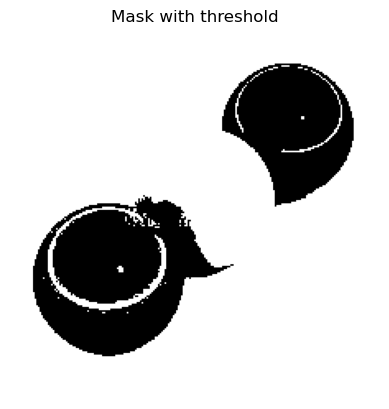

In [12]:
gray_balls = cv2.cvtColor(balls, cv2.COLOR_RGB2GRAY)

# Apply global thresholding
threshold_value = 90
_, binary_image = cv2.threshold(gray_balls, threshold_value, 255, cv2.THRESH_BINARY)

# display the uncovered areas in white and the covered areas in black
binary_image = cv2.cvtColor(binary_image, cv2.COLOR_BGR2RGB)

plt.imshow(binary_image)
plt.title("Mask with threshold")
plt.axis("off")


## Convolutions, Kernels and Transformations

### Convolutions:

The mathematical formalisation of convolutions:

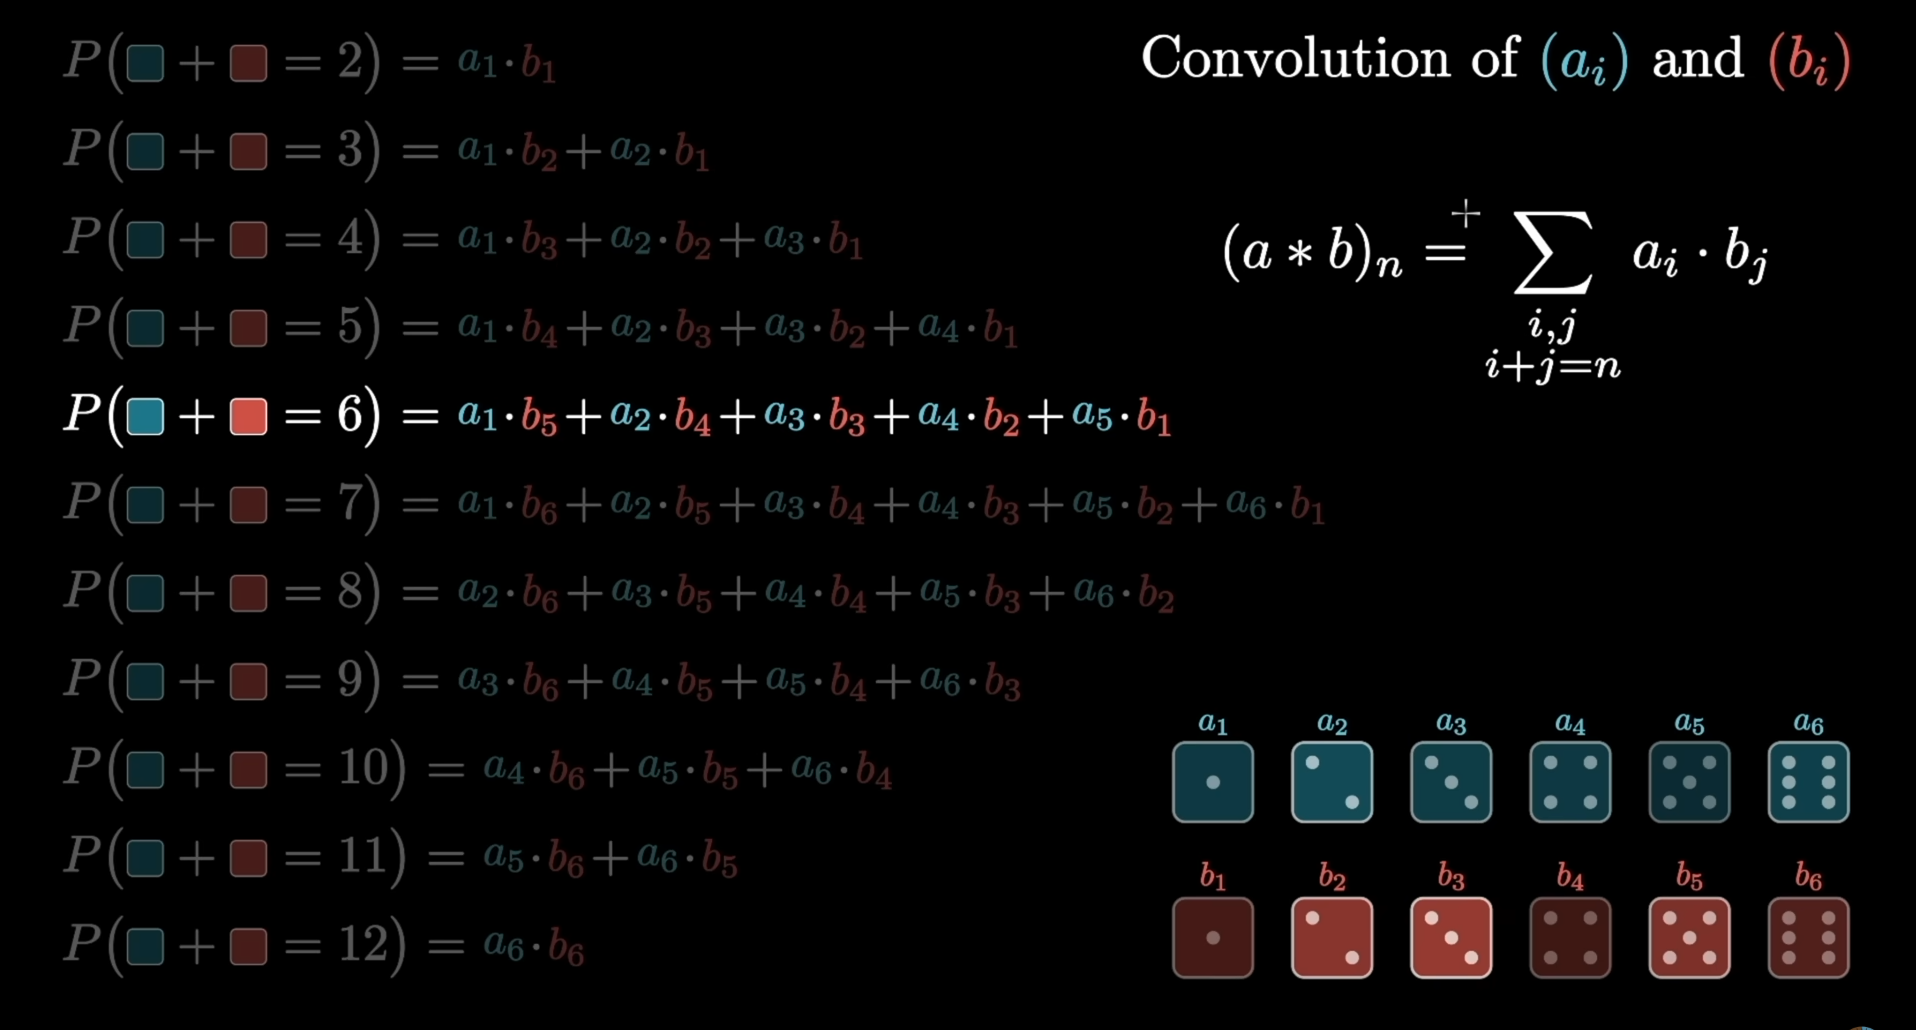

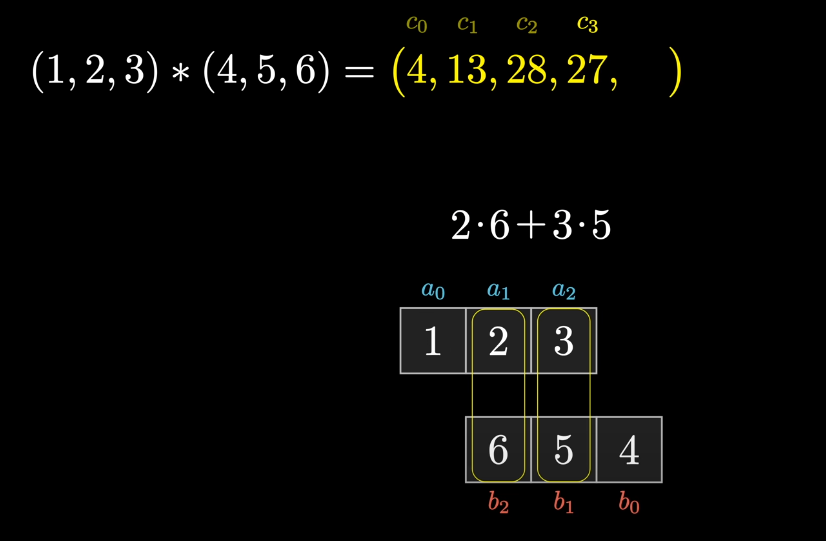

This represents example of a convolution between 2 arrays. Can you help figure out the last item on the list?

### Kernels:

A kernel is essentially a matrix that is convoluted with all pixels in an image. It performs key functions like Blurring, Sharpening, Edge Detection etc. in the context of image modification.

### The moving average example : Merging kernels and convolutions.

Here, we perform a convolution and store the output into a row.

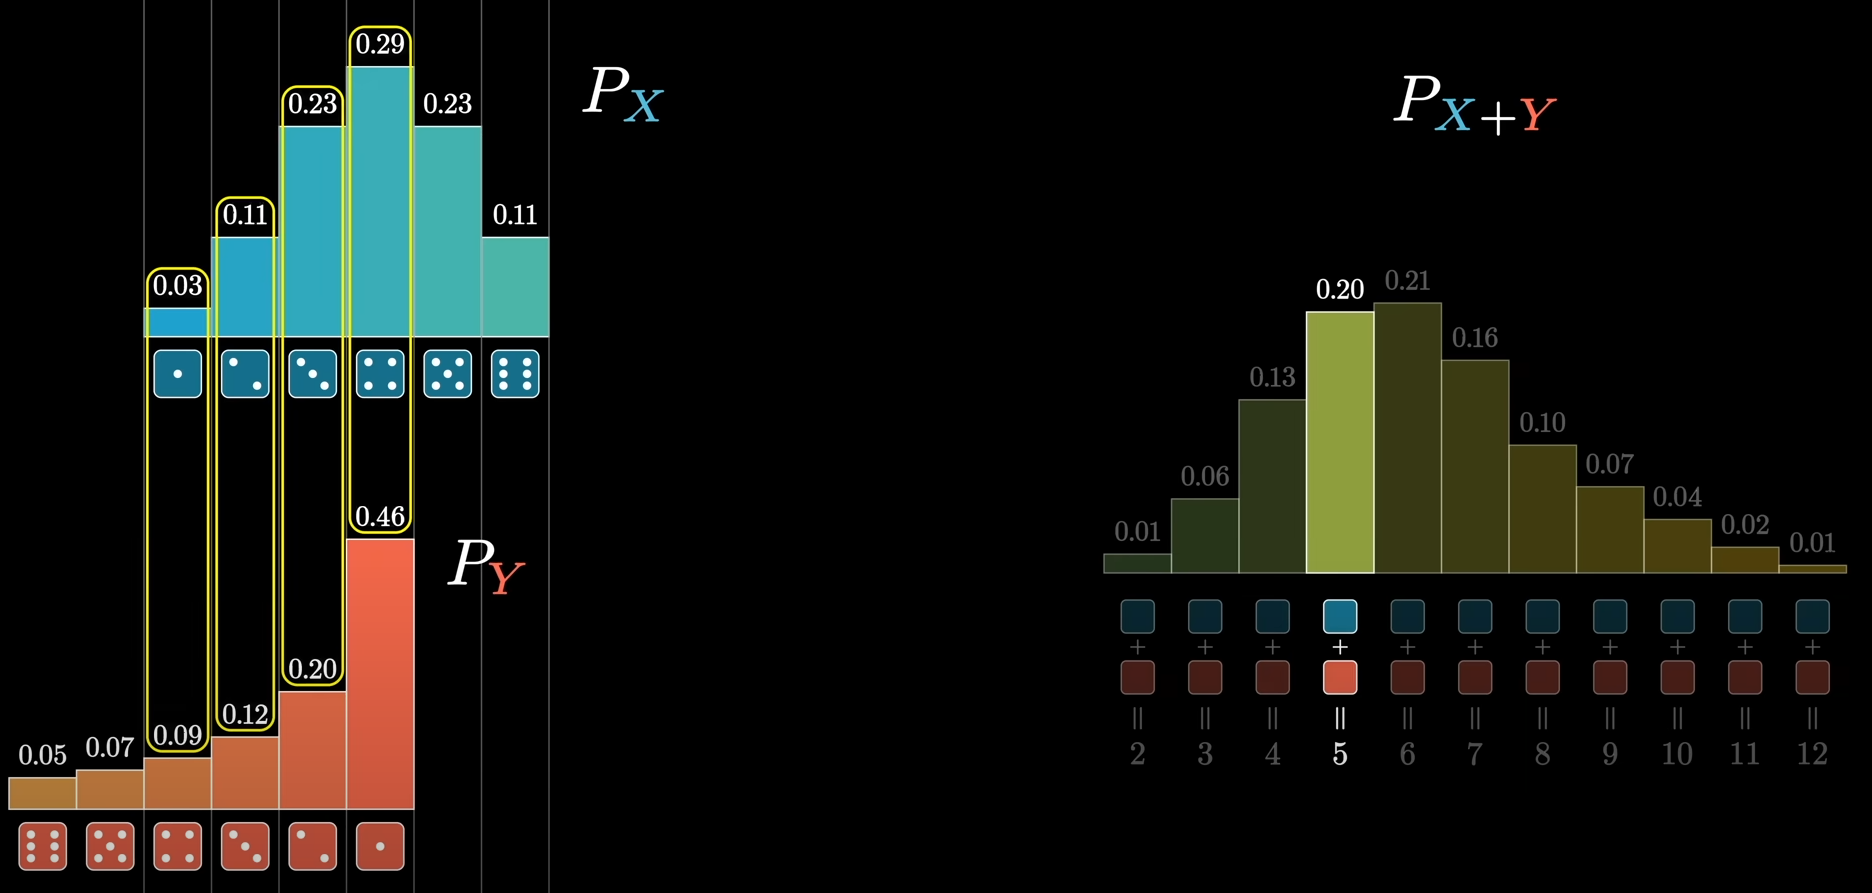

Let's see this come to life with a row of values:

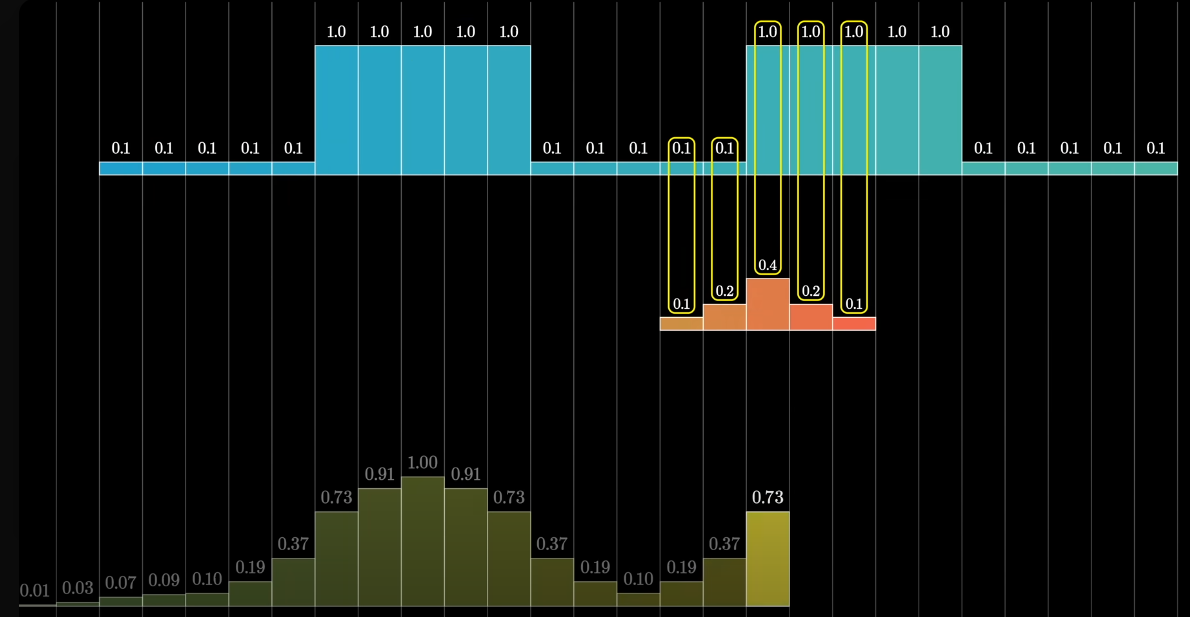

Here's a 2D analogue of this same convolution. Notice that, above, the convolution smoothens out the data. In an image analogue - this means we're blurring the image!

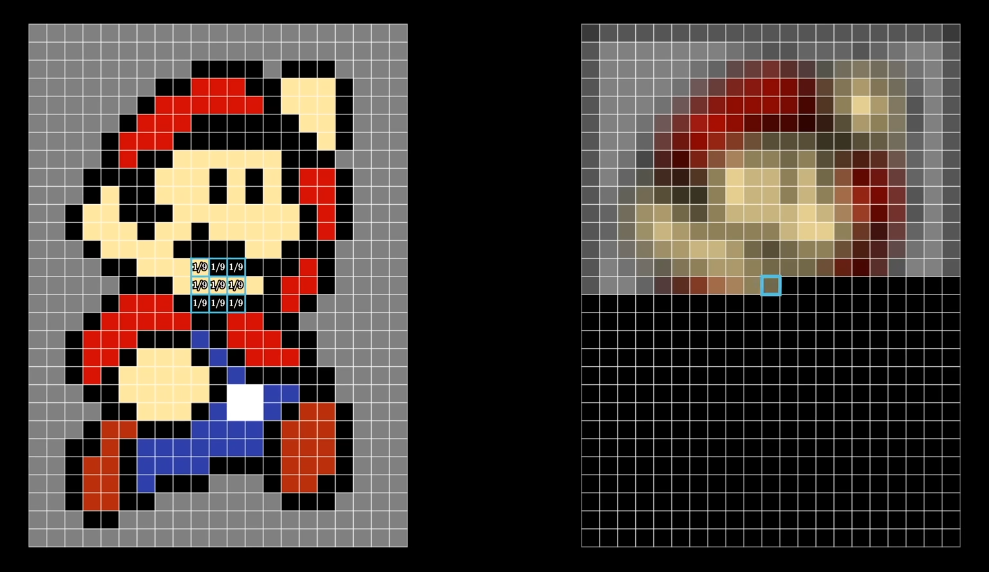

Above, a 3x3 kernel adds up all the surrounding pixels values, x 1/3, and stores that value in the central pixel.

Below is a better illustrated example of a kernel acting on a 2D array of pixels:

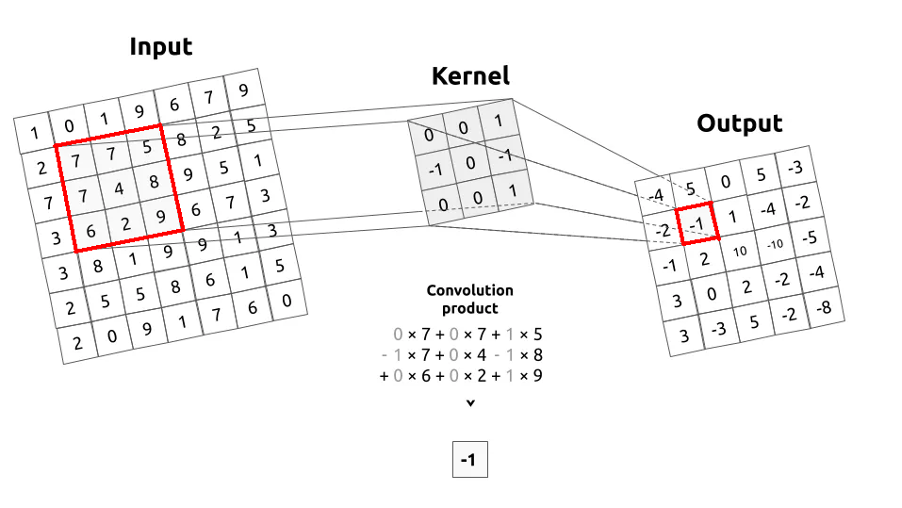

It is important to note that convolutions with kernels lead to dimensionality reduction.

If an image / 2D array has a size (n, n);
and the kernel acting on it has a size (m, m);
the resultant image has a size of (n - m + 1, n - m + 1)

### Transformations:

Transformations change the position and/or orientation of the image. OpenCV has pre-made transformations for scaling/rotating images.

### Kernels and Convolutions

Text(0.5, 1.0, 'Sharpened')

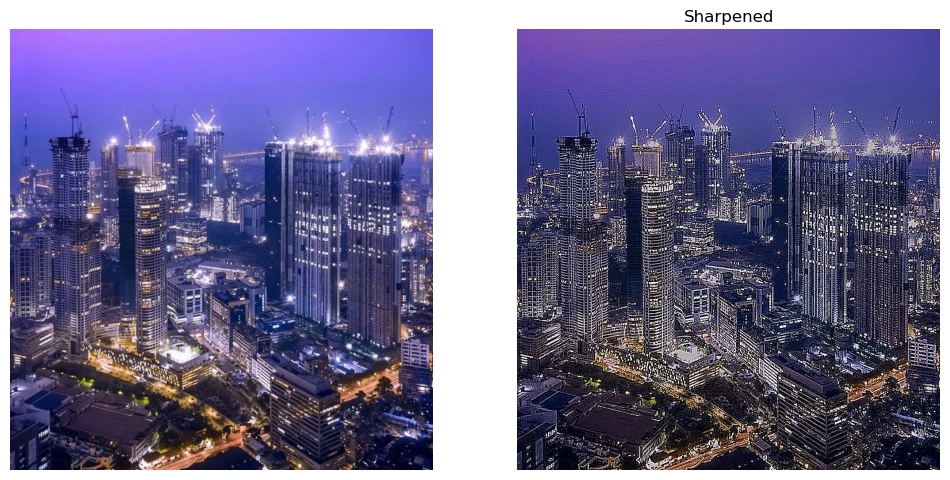

In [24]:
mumbai = cv2.imread('mumbai.jpg', 1)
mumbai = cv2.cvtColor(mumbai, cv2.COLOR_BGR2RGB)

# a sharpening kernel - sharpens the image
kernel = np.array([[-1, -1, -1],
                   [-1,  9, -1],
                   [-1, -1, -1]])

# scaling the kernel - sharpeness factor
kernel = 0.7 * kernel

# apply the convolution
output = cv2.filter2D(mumbai, -1, kernel)

fig, (a1, a2) = plt.subplots(1,2, figsize=(12, 14))
a1.imshow(mumbai)
a1.axis("off")
a2.imshow(output)
a2.axis("off")
plt.title("Sharpened")


### Transformations - Rotation and Scaling

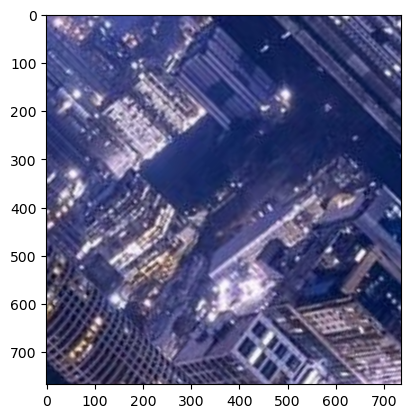

In [27]:
(h, w) = mumbai.shape[:2]

# rotation parameters
angle = 45  # degrees
scale = 3.3  # scaling factor
center = (w // 2, h // 2)  # rotate around the center

# rotation transformation matrix
M = cv2.getRotationMatrix2D(center, angle, scale)

# performing the rotation
rotated = cv2.warpAffine(mumbai, M, (w, h))

plt.imshow(rotated)

## Blurring the Image

Text(0.5, 1.0, 'Blurred')

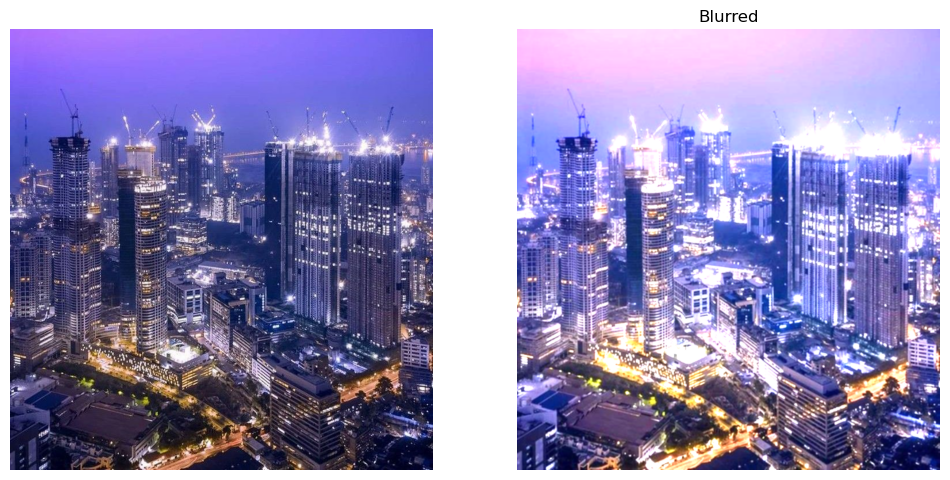

In [14]:
# a blurring kernel - blurs the image
kernel = np.array([[1, 1, 1],
                   [1,  1, 1],
                   [1,1, 1]])

# blur factor - adjust to blur more
kernel = 0.2 * kernel

# apply the convolution
output = cv2.filter2D(mumbai, -1, kernel)

fig, (a1, a2) = plt.subplots(1,2, figsize=(12, 14))
a1.imshow(mumbai)
a1.axis("off")
a2.imshow(output)
a2.axis("off")
plt.title("Blurred")


### You May Ask:
How can I convolute a 2D matrix onto a 3D RGB image?
Well, cv2.filter2d(), by default, applies the same 2D matrix onto all 3 channels - R, G, B. 

## Canny Edge Detection

(-0.5, 224.5, 224.5, -0.5)

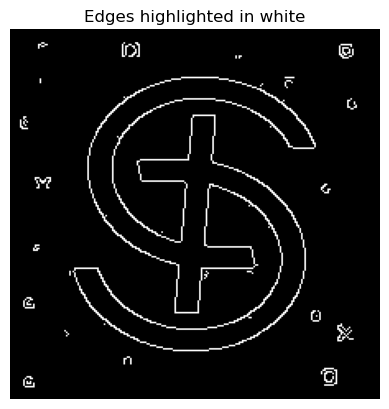

In [15]:
img = cv2.imread('iecse.jpeg', 1)

# Canny: image, threshold1, threshold2
edges = cv2.Canny(img, 100, 200)
edges_RGB = cv2.cvtColor(edges, cv2.COLOR_BGR2RGB)

plt.title("Edges highlighted in white")
plt.imshow(edges_RGB)
plt.axis("off")

## Detecting Shapes in OpenCV

(<matplotlib.image.AxesImage at 0x7467300880d0>,
 Text(0.5, 1.0, 'Detected'),
 (-0.5, 999.5, 352.5, -0.5))

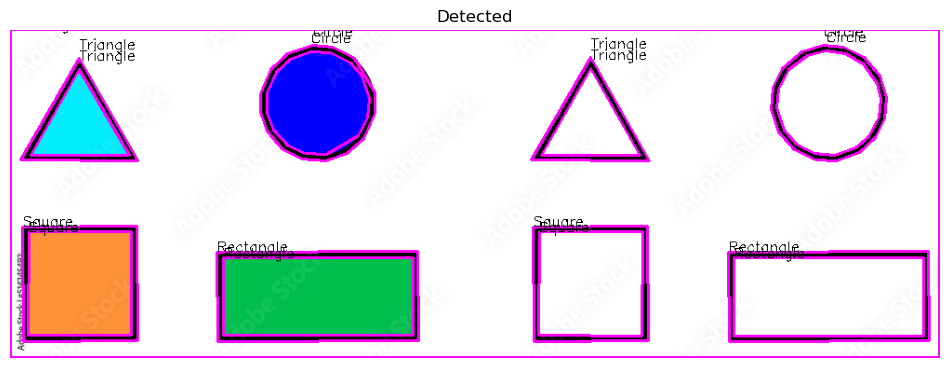

In [16]:
img = cv2.imread("shapes.jpg")
img_default = cv2.imread("shapes.jpg") # storing the default image for comparison

# grayscale
imgGry = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# binary thresholding
ret , threshold = cv2.threshold(imgGry, 50, 255, cv2.THRESH_BINARY)

# detecting contours in the image
contours , hierarchy = cv2.findContours(threshold, cv2.RETR_TREE, cv2.CHAIN_APPROX_NONE)

for contour in contours:
    
    # epsilon for RDP - smaller for more detailed shapes
    epsilon = 0.01 * cv2.arcLength(contour, True)
    
    # array of coordinates for the approximate shape
    approx = cv2.approxPolyDP(contour, epsilon, True)
    
    cv2.drawContours(img, [approx], 0, (255, 0, 255), 2)
    
    # positions for text labels - slightly above the shape
    x = approx.ravel()[0]
    y = approx.ravel()[1] - 10
    
    # len(approx) refers to the number of detected vertices in the shape
    
    if len(approx) == 3:
        cv2.putText( img, "Triangle", (x, y), font, 0.5, (0, 0, 0), )
    
    elif len(approx) == 4 :
        x, y , w, h = cv2.boundingRect(approx)
        
        aspectRatio = float(w)/h # ratio of width to height
        
        # if w ~= h it's a square else it's a rectangle 
        if aspectRatio >= 0.95 and aspectRatio < 1.05:
            cv2.putText(img, "Square", (x, y), font, 0.5, (0, 0, 0))
        else:
            cv2.putText(img, "Rectangle", (x, y), font, 0.5, (0, 0, 0))
        
    elif len(approx) > 10:
        cv2.putText(img, "Circle", (x, y), font, 0.5, (0, 0, 0))

plt.figure(figsize=(12, 6))
plt.imshow(img), plt.title('Detected'), plt.axis("off")

## Haar Cascades

(-0.5, 1199.5, 479.5, -0.5)

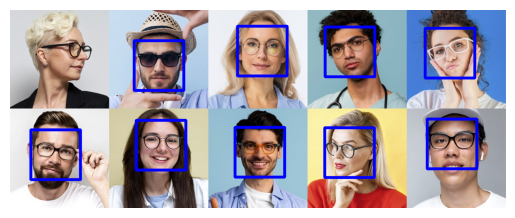

In [17]:
face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')

faces = cv2.imread("faces.jpg", 1)

# detecting faces. it's usually best practice to convert the image into grayscale
faces_detected = face_cascade.detectMultiScale(faces, 5, 3)

# drawing rectangles around faces - detect returns x, y coordinates and height, width values
for (x, y, w, h) in faces_detected:
    cv2.rectangle(faces, (x, y), (x+w, y+h), (255, 0, 0), 5)
    
faces = cv2.cvtColor(faces, cv2.COLOR_BGR2RGB)
plt.imshow(faces)
plt.axis("off")